# Module 9: Creating Wide Panoramas
In this notebook, we look at how to combine a series of overlapping photos into a single, wide-angle panoramic image. It is highly useful in drone mapping applications where a drone needs to piece together individual aerial grid shots into a single map.

In [2]:
# Import Libraries
import os
import cv2
import math
import glob
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

%matplotlib inline

In [3]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)
URL = r"https://www.dropbox.com/s/0o5yqql1ynx31bi/opencv_bootcamp_assets_NB9.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB9.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)  

### 1. Loading Batches of Images Programmatically (`glob.glob`)
Instead of typing out code to load every single image file manually, we use Python's built-in `glob` library to search our directories dynamically.
* **How it works:** `glob.glob("boat/*")` acts like a search filter, finding every file inside the boat folder automatically. 
* **Sorting Matters:** We call `.sort()` because the images must be processed in sequential order from left-to-right (or right-to-left). If the sequence is scrambled, the matching math will break down.
* **Color Processing Loop:** A quick `for` loop cycles through our list, reads each image using `cv2.imread()`, and fixes the color mapping from BGR to RGB so they render naturally on our screen.

In [4]:
# Read Images

imagefiles = glob.glob(f"boat{os.sep}*")
imagefiles.sort()


images = []
for filename in imagefiles:
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

num_images = len(images)

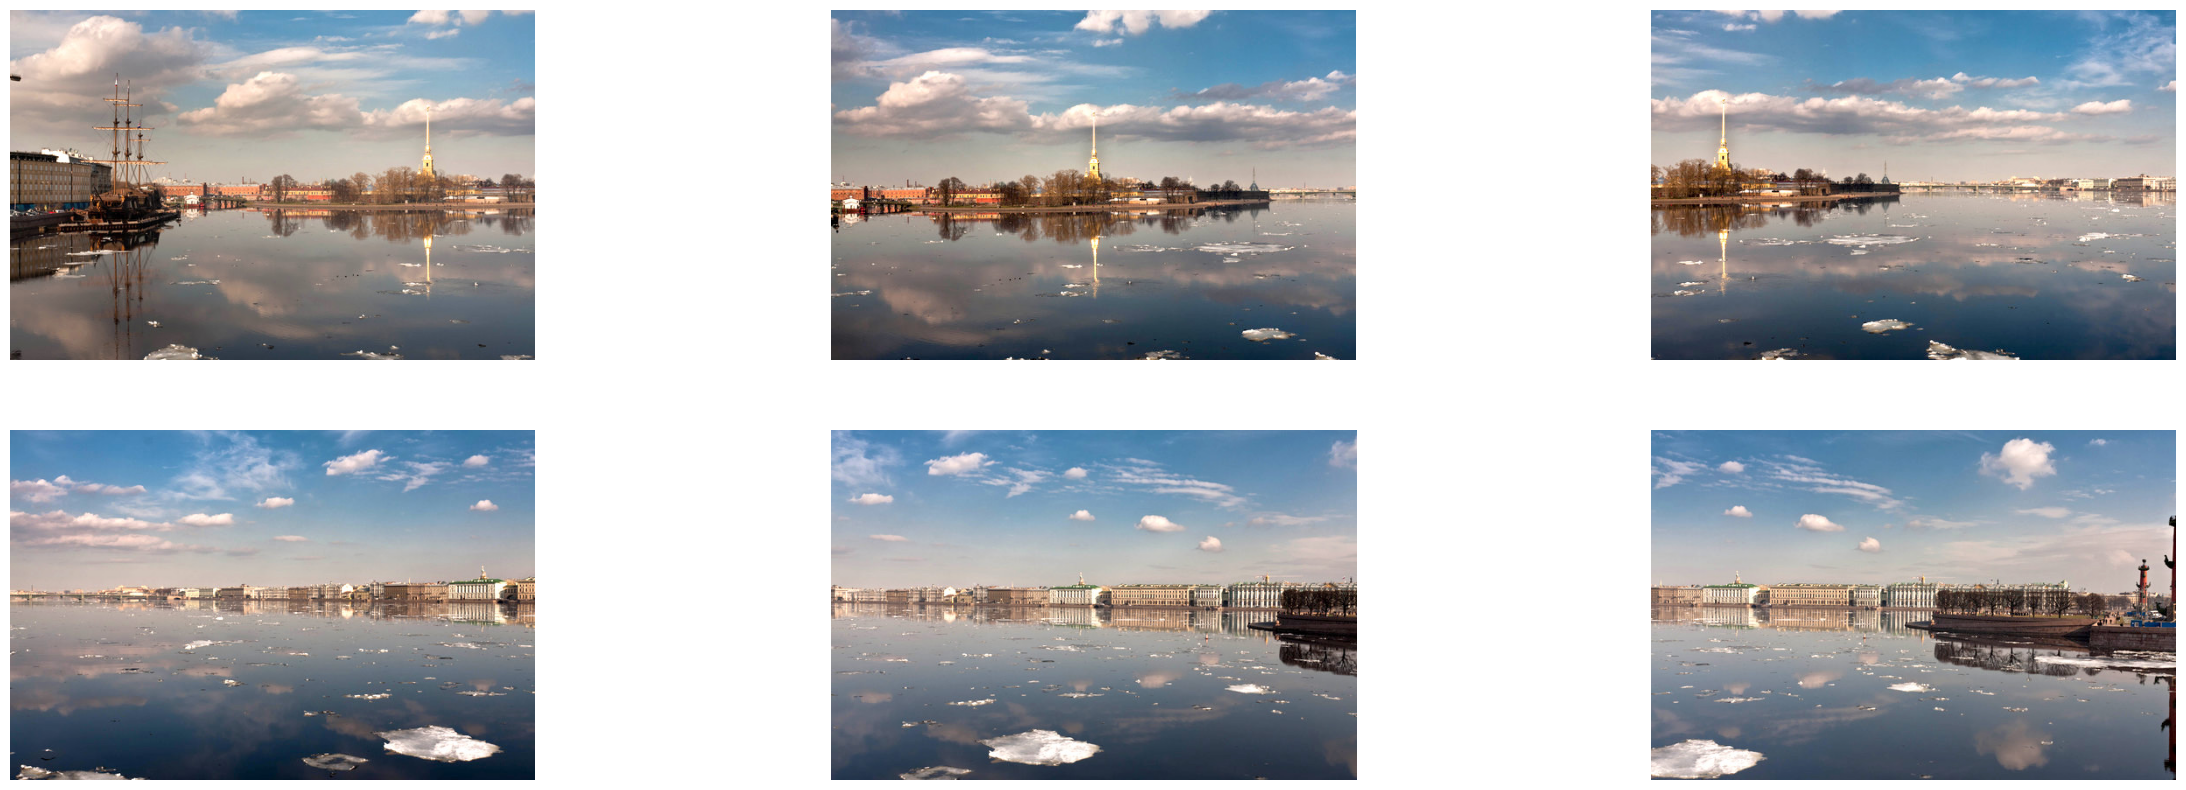

In [5]:
# Display Images
plt.figure(figsize=[30, 10])
num_cols = 3
num_rows = math.ceil(num_images / num_cols)
for i in range(0, num_images):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.axis("off")
    plt.imshow(images[i])

### 2. The OpenCV Stitching Engine (`cv2.Stitcher_create`)
Instead of writing thousands of lines of math manually to detect features, calculate matching coordinate pairs, and align perspectives, OpenCV provides a pre-packaged tool called the `Stitcher` class.



**What happens behind the scenes:**
1. **Feature Extraction:** The algorithm finds unique landmarks across all images.
2. **Matching & Homography:** It finds where those landmarks overlap and figures out how to twist or rotate the images to line up.
3. **Blending:** It blends the seams smoothly so we don't see harsh, overlapping lines where the photos meet.
4. **Status Check:** It returns a `status` flag. If `status == 0`, the compilation succeeded perfectly.

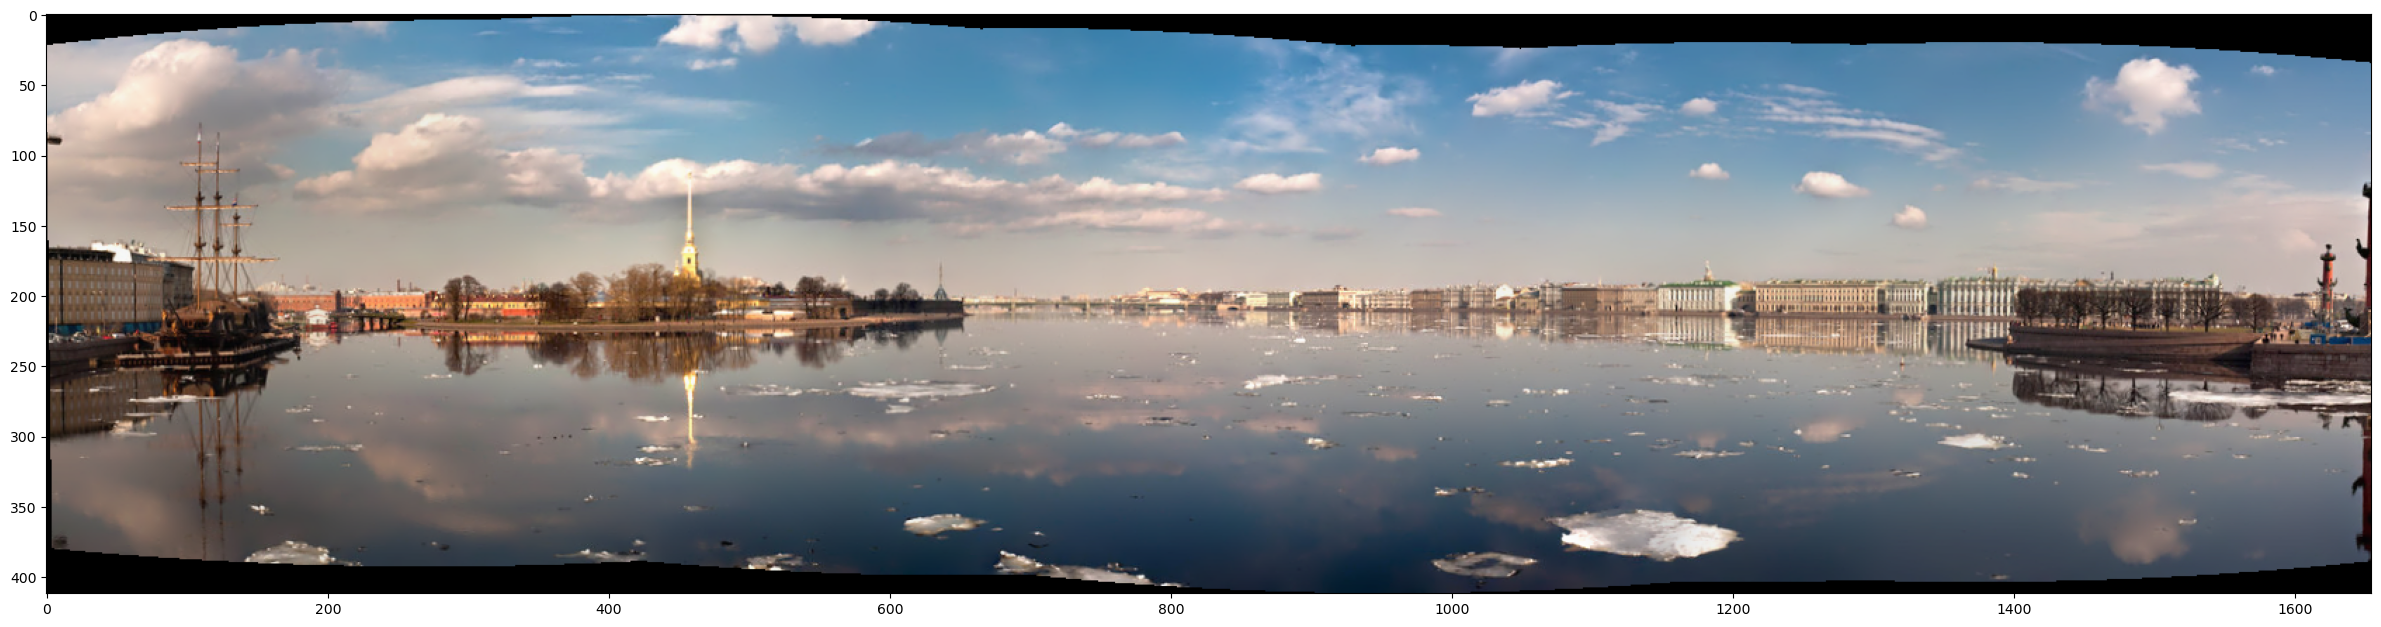

In [6]:
# Stitch Images
stitcher = cv2.Stitcher_create()
status, result = stitcher.stitch(images)

if status == 0:
    plt.figure(figsize=[30, 10])
    plt.imshow(result)

### 3. Automated Panorama Edge Trimming (Cropping Black Borders)
Because perspective warping creates irregular, wavy black margins around our final stitched panorama, we apply automated contour detection to extract a clean, solid rectangle.

**The Pipeline Logic:**
1. **Binary Bitmap Creation:** Convert the colorful panorama to grayscale and apply global thresholding (`cv2.threshold`). This creates a binary mask where the active image area is pure white (255) and the black void is pure black (0).
2. **Contour Analysis:** Use `cv2.findContours` to locate the outer boundaries of the white shape. We isolate the largest contour to skip any random pixel noise.
3. **Bounding Box Isolation:** We find the initial `cv2.boundingRect` of our shape.
4. **Iterative Rectating Shrinking:** Because a standard bounding box will still catch the wavy black corners, we run a `while` loop that checks the pixel counts using `cv2.countNonZero`. The loop shrinks the rectangle coordinates inward from all four sides until the bounding box contains 100% solid, non-black image pixels.

Panorama borders successfully cropped and saved to disk!


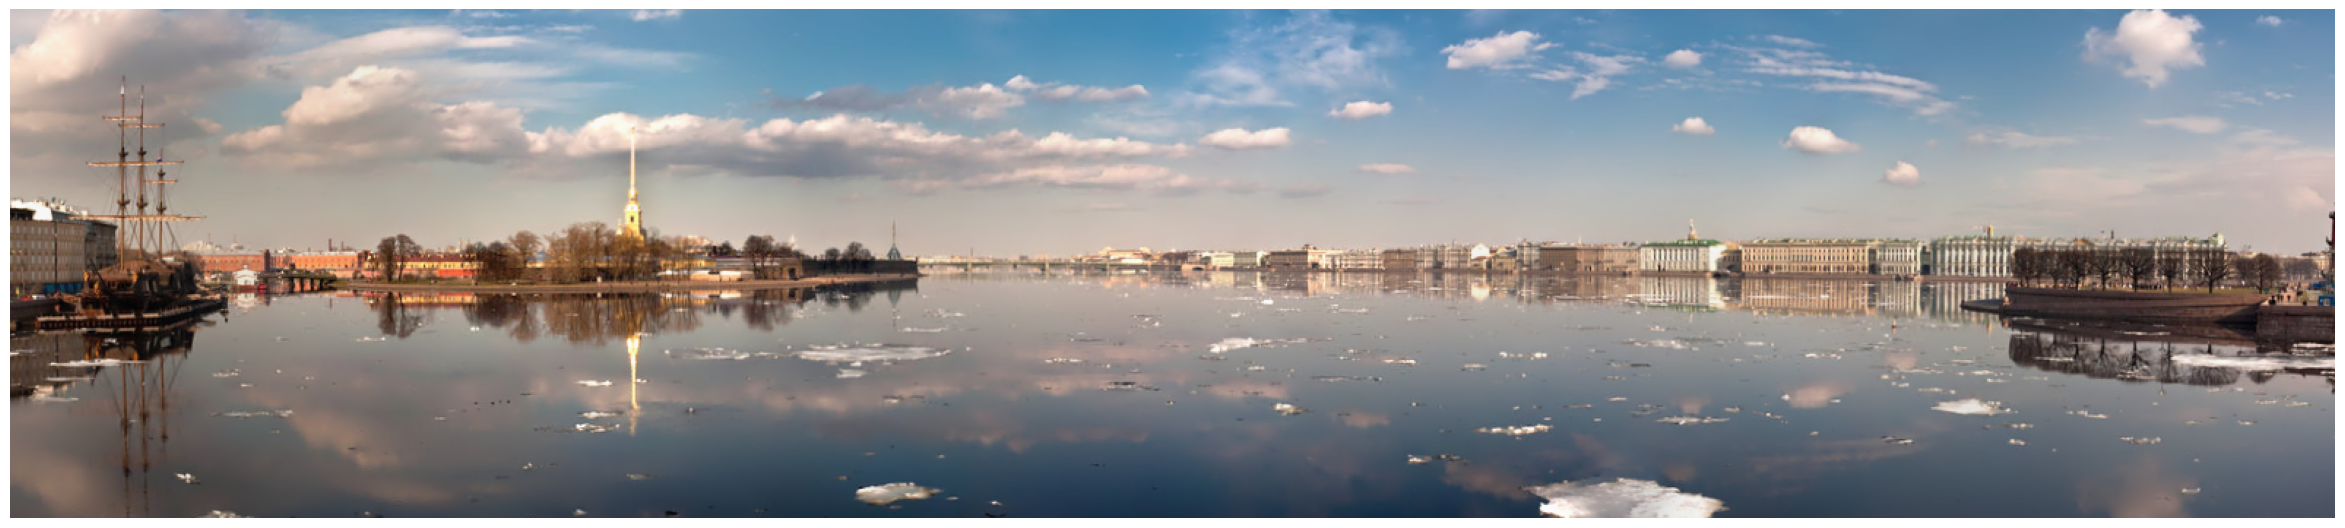

In [9]:
if status == 0:
    # 1. Convert the stitched color image to grayscale
    gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    
    # 2. Create a binary mask (bitmap). Pixels > 0 become 255 (white), borders stay 0 (black)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    
    # 3. Find all external contours and isolate the largest one
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # 4. Draw a solid white template mask matching our panorama's shape
    contour_mask = np.zeros(thresh.shape, dtype=np.uint8)
    cv2.drawContours(contour_mask, [largest_contour], 0, 255, -1)
    
    # 5. Get the baseline bounding box rectangle of the contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # 6. Iteratively shrink the rectangle inward until it contains zero black pixels
    while cv2.countNonZero(contour_mask[y:y+h, x:x+w]) < (w * h):
        x += 1
        y += 1
        w -= 2
        h -= 2
        
    # 7. Extract the final clean crop from the original color image matrix
    cropped_panorama = result[y:y+h, x:x+w]
    
    # 8. Display the final results
    plt.figure(figsize=[30, 10])
    plt.imshow(cropped_panorama)
    plt.axis("off")
    
    cv2.imwrite("panorama_cropped.png", cv2.cvtColor(cropped_panorama, cv2.COLOR_RGB2BGR))
    print("Panorama borders successfully cropped and saved to disk!")
else:
    print("Stitching failed, cannot execute border cropping pipeline.")